In [1]:
import os
import sys
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
#import nipes_data_fcts as nidf
import me_data_fcts as medf
#from statannotations.Annotator import Annotator
import umap
from sklearn.preprocessing import StandardScaler


In [2]:
# if you modify me_data_fcts.py and want to reload without restarting the kernel
import importlib
importlib.reload(medf)

<module 'me_data_fcts' from '/home/leni/git/AREFramework/experiments/scripts/me_data_fcts.py'>

In [3]:
repo_folder = "/media/leni/DATADRIVE1/alife_2025/"
experiments = {
    "directory" :  ['meimflat', 'meimhill', 'meimholes', 'meimobs', 'meimrough', 'meimholly' ],
    "name" :       ['flat', 'hill', 'holes', 'obstacles', 'rough', 'hollyrood'],
    "print_name" : ['Flat', 'Hill', 'Holes', 'Obstacles', 'Rough', 'Hollyrood'],
}

In [4]:
def load_experiment(name, folders):
    experiments_loaded = 0
    exp_fits = []
    for folder in folders:
        ids, parents, fitnesses, evals, deltas, replicate_index = medf.load_fitness(folder + "/fitness.csv")
        eval_times = medf.load_comp_time_dict(folder + "/times.csv")
        fits = [[i, p[0], p[1], eval_times[i][0]/(1000000*3600), eval_times[i][1]/(1000000*3600), f, folder, r] 
                for i, p, f, r in zip(ids,parents,fitnesses, replicate_index)]
        exp_fits += fits
        experiments_loaded += 1
        print(folder, " -- Robots: ", len(ids))
    fit_data = pd.DataFrame(data=exp_fits,columns=[      "robot index",
                                                         "parent 1",
                                                         "parent 2",
                                                         "evaluation time",
                                                         "time",
                                                         "fitness",
                                                         "replicate", 
                                                         "replicate_index"])
    fit_data["environment"] = name
    print("Total experiments loaded: ", experiments_loaded, "-- Total robots: ", len(fit_data))
    return fit_data

In [5]:
def load_morphology(name, folders):
    exp_descs = []
    experiments_loaded = 0
    for folder in folders:
        #parent_ids = medf.load_parent_pool(folder + "/parent_pool.csv")
        descriptors = medf.load_feature_descriptor(folder + "/morph_features.csv")
        #print(descriptors[-1])
        descs = [[int(d[0])] + d[1:5] + [d[5]*16,
                                         d[6]*16,
                                         d[7]*16,
                                         d[8]*16]
                                           + d[9:]  + [folder] 
                 for d in descriptors]
        #print(descs[-1])
        #parent_descs += medf.filter_to_parent_pool(descs,parent_ids)
        exp_descs += descs        
        print(folder, " -- Robots: ", len(descs))
        experiments_loaded += 1
    data = pd.DataFrame(data=exp_descs,columns=[
                                                            "robot index",
                                                            "width",
                                                            "depth",
                                                            "height",
                                                            "voxels",
                                                            "wheels",
                                                            "sensors",
                                                            "limbs",
                                                            "casters",
                                                            "norm",
                                                            "skeleton norm",
                                                            "components norm",
                                                            "replicate_index", 
                                                            "replicate"])
    data["environment"] = name
    print("Total experiments loaded: ", experiments_loaded, "-- Total robots: ", len(data))
    return data

In [6]:
# Load fitness data
robot_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        for fold in os.listdir(repo_folder + exps + '/' + folder):
            folders.append(repo_folder + exps + '/' + folder + '/' + fold)
    data = load_experiment(experiments['name'][idx], folders)
    robot_data.append(data)


meimflat
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_1/meim_11_3_17-59-57-7269-4229270083  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_10/meim_12_3_1-54-59-9138-4171306948  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_2/meim_11_3_17-59-56-6384-2102594713  -- Robots:  10000


/media/leni/DATADRIVE1/alife_2025/meimflat/55742_3/meim_11_3_17-59-58-8527-4068923784  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_4/meim_11_3_17-59-57-7377-2053156979  -- Robots:  10036
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_5/meim_11_3_17-59-57-7862-293875990  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_6/meim_11_3_17-59-57-7467-1188062065  -- Robots:  10002
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_7/meim_11_3_17-59-59-9003-1516430376  -- Robots:  10024
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_8/meim_11_3_19-16-10-816-2370462392  -- Robots:  10046
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_9/meim_12_3_1-34-14-4030-2971763921  -- Robots:  10004
/media/leni/DATADRIVE1/alife_2025/meimflat/56265_1/meim_17_3_21-46-8-8472-1119555096  -- Robots:  10048
/media/leni/DATADRIVE1/alife_2025/meimflat/56265_10/meim_18_3_6-31-31-1271-1925515686  -- Robots:  10047
/media/leni/DATADRIVE1/alife_2025/meimflat/56265_2/meim_17_

In [33]:
# loading descriptor data
robot_desc_data = []
for idx, exps in enumerate(experiments['directory']):
    print(exps)
    folders = []
    data = []
    for folder in os.listdir(repo_folder + exps):
        for fold in os.listdir(repo_folder + exps + '/' + folder):
            folders.append(repo_folder + exps + '/' + folder + '/' + fold)
    data = load_morphology(experiments['name'][idx], folders)
    robot_desc_data.append(data)

meimflat
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_1/meim_11_3_17-59-57-7269-4229270083  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_10/meim_12_3_1-54-59-9138-4171306948  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_2/meim_11_3_17-59-56-6384-2102594713  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_3/meim_11_3_17-59-58-8527-4068923784  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_4/meim_11_3_17-59-57-7377-2053156979  -- Robots:  10036
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_5/meim_11_3_17-59-57-7862-293875990  -- Robots:  10000
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_6/meim_11_3_17-59-57-7467-1188062065  -- Robots:  10002
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_7/meim_11_3_17-59-59-9003-1516430376  -- Robots:  10024
/media/leni/DATADRIVE1/alife_2025/meimflat/55742_8/meim_11_3_19-16-10-816-2370462392  -- Robots:  10046
/media/leni/DATADRIVE1/alife_2025/meimflat/55742

In [8]:
# Concat all the parents data
fit_data = pd.concat(robot_data).reset_index(drop=True)
#fit_data = fit_data[fit_data["replicate_index"] <= 6000]

# Selecting highest robot per replicate
fit_max_data = []
for env in experiments["name"]:
    tmp_data = fit_data.loc[fit_data["environment"] == env]
    for rep in tmp_data["replicate"].drop_duplicates():
        tmp_data2 = tmp_data.loc[tmp_data["replicate"] == rep]
        fit_max_data.append(pd.DataFrame(tmp_data2.max(numeric_only=True)).transpose())
        fit_max_data[-1]["replicate"] = rep
        fit_max_data[-1]["environment"] = env
            
fit_max_data = pd.concat(fit_max_data)
fit_max_data.index = [i for i in range(len(fit_max_data))]

In [37]:
desc_data = pd.concat(robot_desc_data).reset_index(drop=True)
desc_data = pd.merge(desc_data, fit_data, how="left",
                     on=["robot index", "replicate", "environment", "replicate_index"])
desc_data = desc_data.drop_duplicates(subset=['robot index','replicate'])
#desc_data = desc_data[desc_data["replicate_index"] <= 6000]


In [38]:
print(desc_data["replicate"])

0          /media/leni/DATADRIVE1/alife_2025/meimflat/557...
1          /media/leni/DATADRIVE1/alife_2025/meimflat/557...
2          /media/leni/DATADRIVE1/alife_2025/meimflat/557...
3          /media/leni/DATADRIVE1/alife_2025/meimflat/557...
4          /media/leni/DATADRIVE1/alife_2025/meimflat/557...
                                 ...                        
1161915    /media/leni/DATADRIVE1/alife_2025/meimholly/56...
1161916    /media/leni/DATADRIVE1/alife_2025/meimholly/56...
1161917    /media/leni/DATADRIVE1/alife_2025/meimholly/56...
1161918    /media/leni/DATADRIVE1/alife_2025/meimholly/56...
1161919    /media/leni/DATADRIVE1/alife_2025/meimholly/56...
Name: replicate, Length: 1161920, dtype: object


# Exploration score

/tmp/ipykernel_22295/1041369847.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(experiments["print_name"])


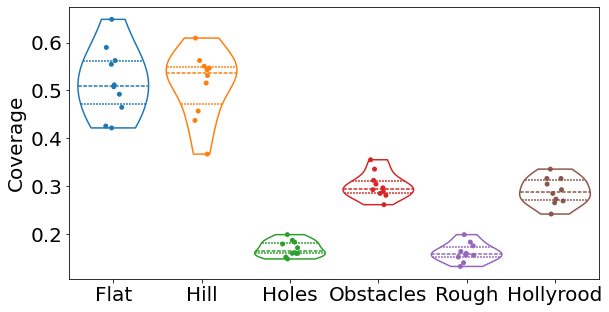

In [10]:
fig = plt.gcf()
fig.set_size_inches(9.5,5)
ax = sns.violinplot(fit_max_data,x="environment",hue="environment",y="fitness",fill=False,inner="quart", cut=0)
sns.stripplot(fit_max_data,x="environment",hue="environment",y="fitness")
ax.set_xlabel("")
ax.set_xticklabels(experiments["print_name"])
ax.set_ylabel("Coverage")
ax.xaxis.label.set_size(20)
ax.yaxis.label.set_size(20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.savefig("img_alife25/exploration_score_nf.png")


In [11]:
avg_fitness_per_replicate_index = fit_data.groupby(['environment', 'replicate_index'])['fitness'].mean().reset_index()
avg_fitness_per_replicate_index.rename(columns={'fitness': 'average_fitness'}, inplace=True)
avg_fitness_per_replicate_index

,environment,replicate_index,average_fitness
0,flat,0,0.024219
1,flat,1,0.033594
2,flat,2,0.032812
3,flat,3,0.027344
4,flat,4,0.019531
...,...,...,...
60261,rough,10043,0.028646
60262,rough,10044,0.021484
60263,rough,10045,0.021484
60264,rough,10046,0.042969


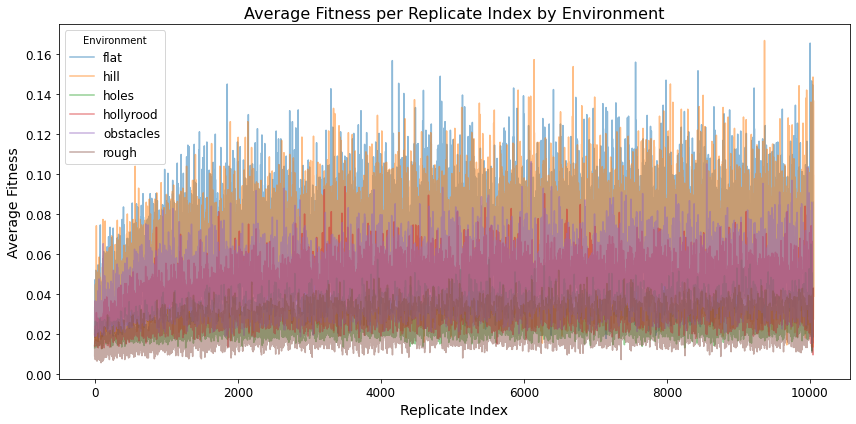

In [12]:
fig = plt.gcf()
fig.set_size_inches(12, 6)
ax = sns.lineplot(
  data=avg_fitness_per_replicate_index,
  x="replicate_index",
  y="average_fitness",
  hue="environment",
  alpha=0.5
)
ax.set_title("Average Fitness per Replicate Index by Environment", fontsize=16)
ax.set_xlabel("Replicate Index", fontsize=14)
ax.set_ylabel("Average Fitness", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title="Environment", fontsize=12)
plt.tight_layout()
plt.show()


# Components diversity

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%')])

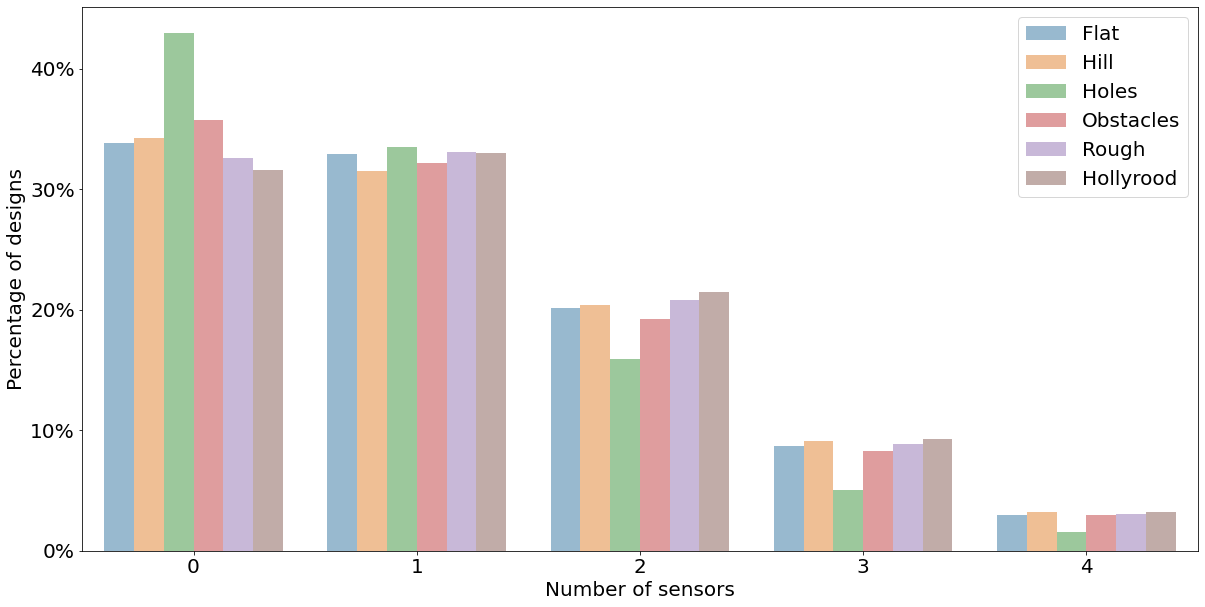

In [16]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['sensors'], normalize='index')
df1 = df.melt(var_name='sensors', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="sensors",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Percentage of designs")
ax.set_xlim([-0.5,4.5])
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 ]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.05, '5%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.15000000000000002, '15%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.25, '25%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.35000000000000003, '35%'),
  Text(0, 0.4, '40%')])

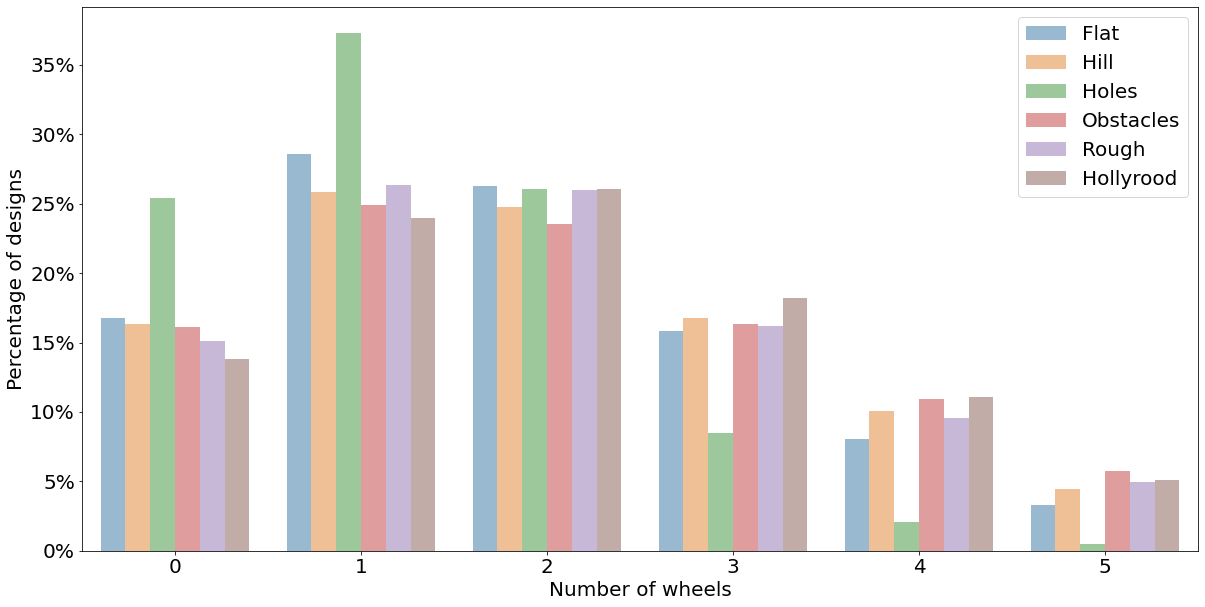

In [17]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['wheels'], normalize='index')
df1 = df.melt(var_name='wheels', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="wheels",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of wheels")
ax.set_ylabel("Percentage of designs")
ax.set_xlim([-0.5,5.5])
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.7000000000000001, '70%')])

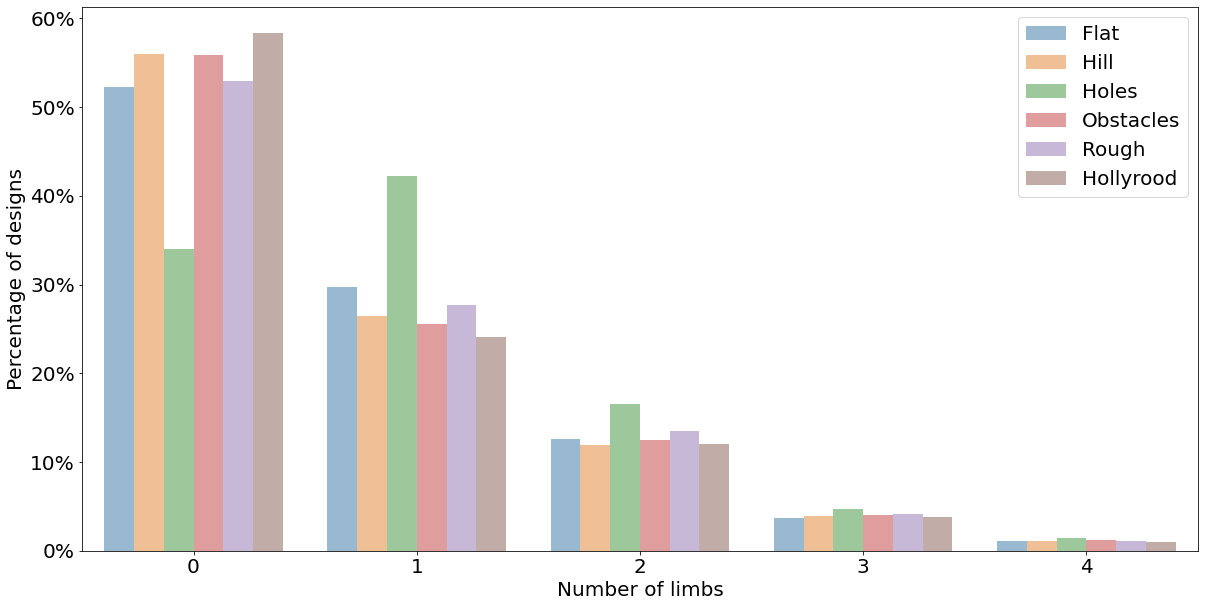

In [18]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['limbs'], normalize='index')
df1 = df.melt(var_name='limbs', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="limbs",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of limbs")
ax.set_ylabel("Percentage of designs")
ax.set_xlim([-0.5,4.5])
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.7000000000000001, '70%'),
  Text(0, 0.8, '80%')])

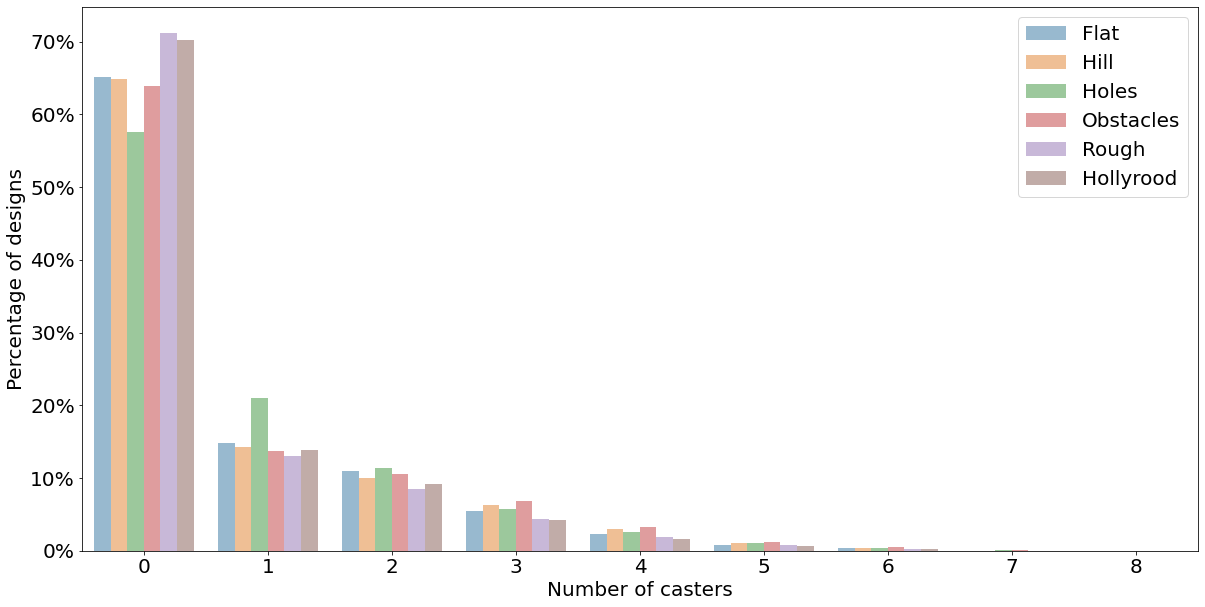

In [20]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['casters'], normalize='index')
df1 = df.melt(var_name='casters', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="casters",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of casters")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

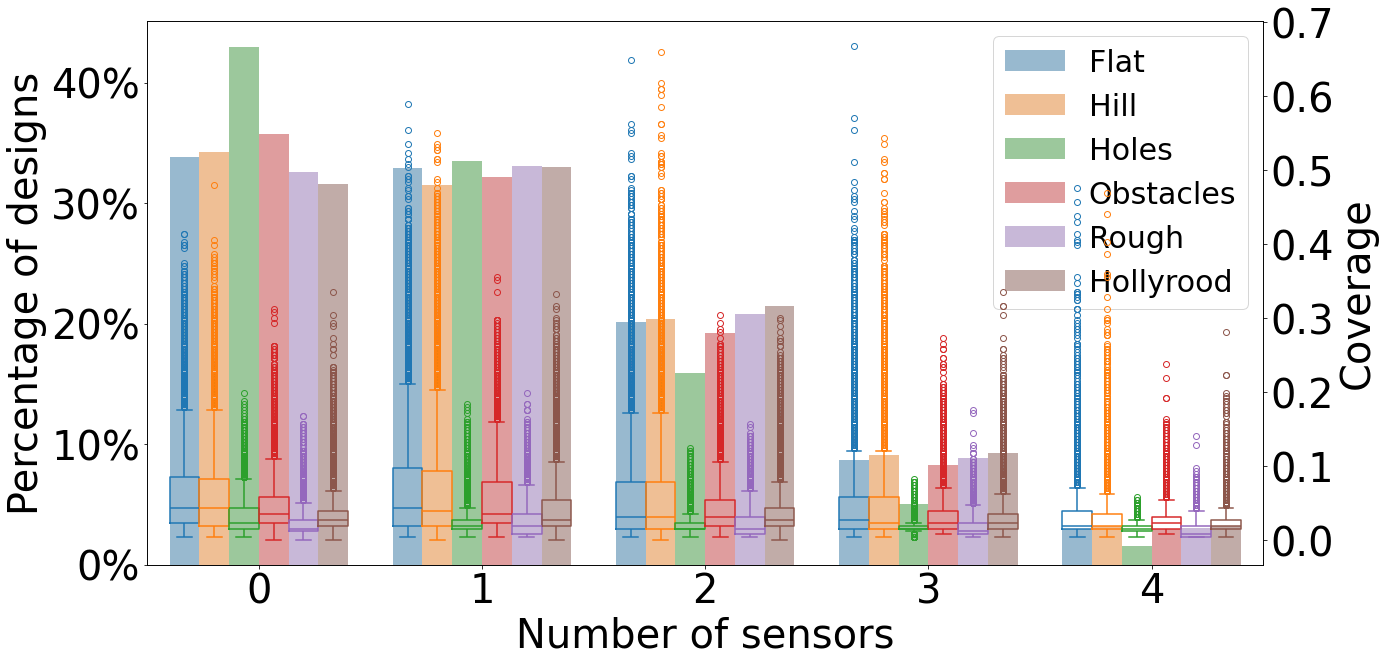

In [15]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['sensors'], normalize='index')
df1 = df.melt(var_name='sensors', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="sensors",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="sensors",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.set_xlim([-0.5,4.5])
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_sensors_score_nf.png")

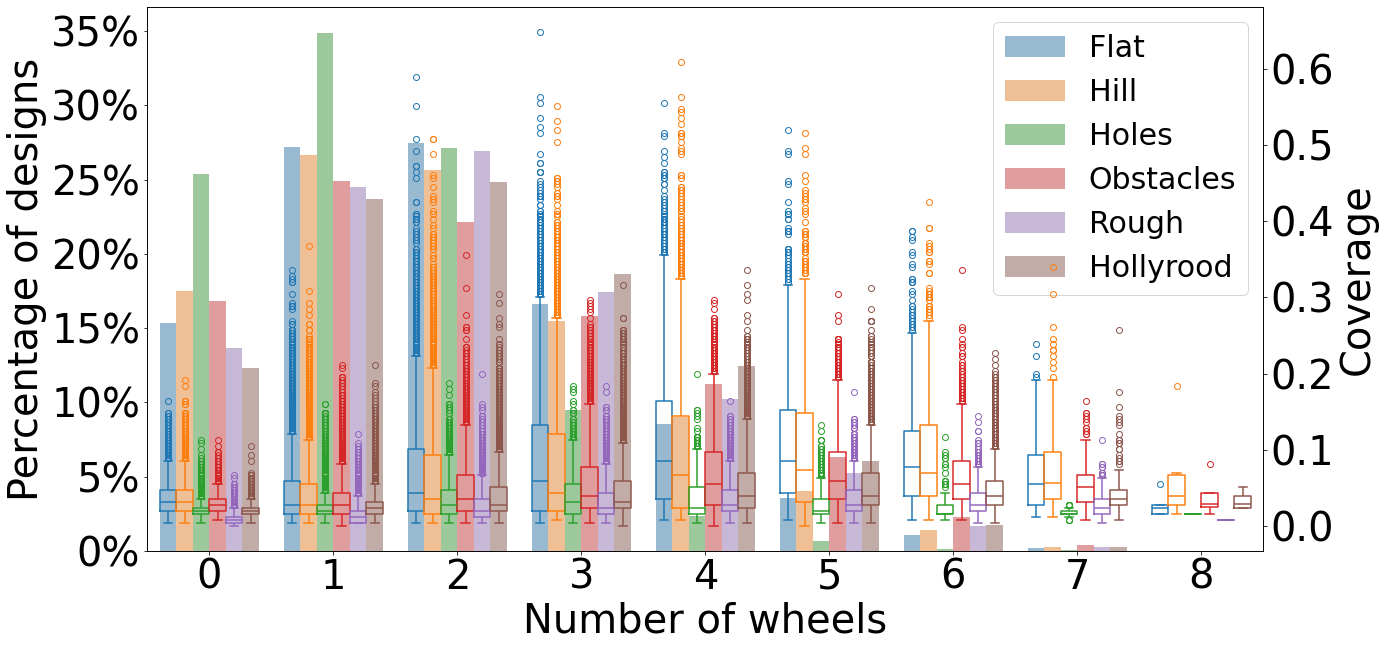

In [22]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['wheels'], normalize='index')
df1 = df.melt(var_name='wheels', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="wheels",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of wheels")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="wheels",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_wheels_score_nf.png")

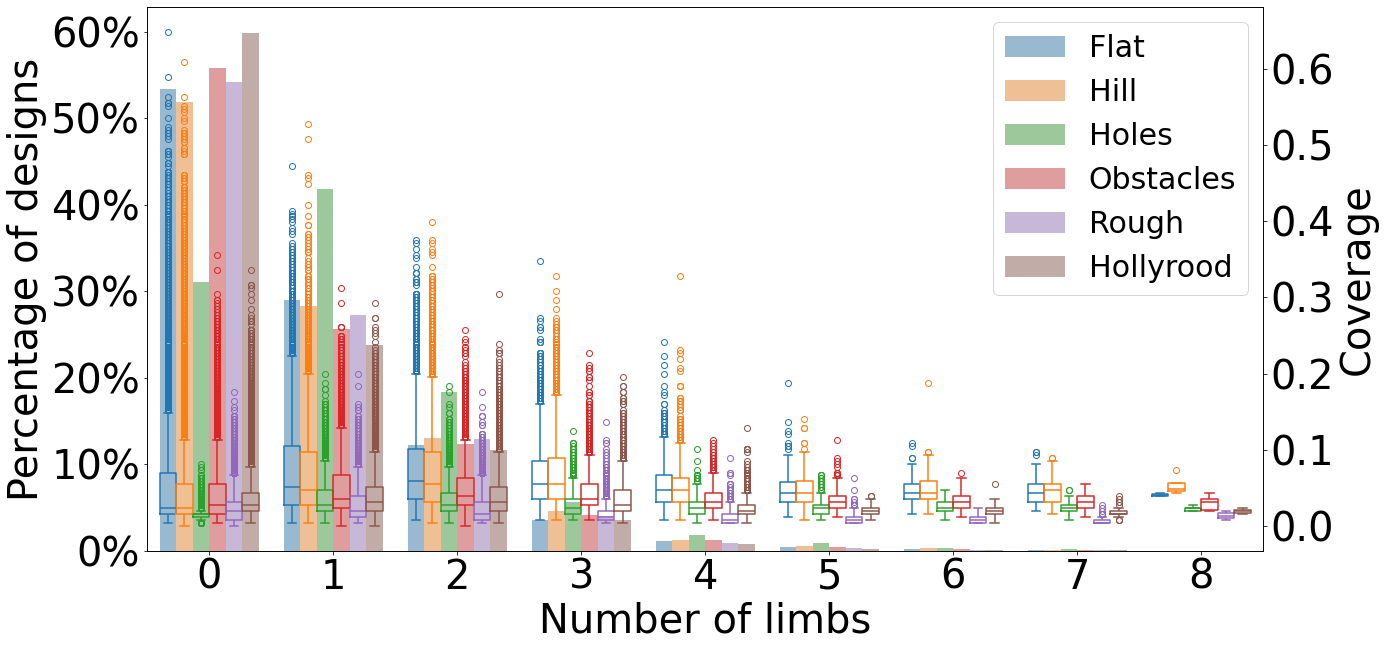

In [23]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['limbs'], normalize='index')
df1 = df.melt(var_name='limbs', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="limbs",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of limbs")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="limbs",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_limbs_score_nf.png")

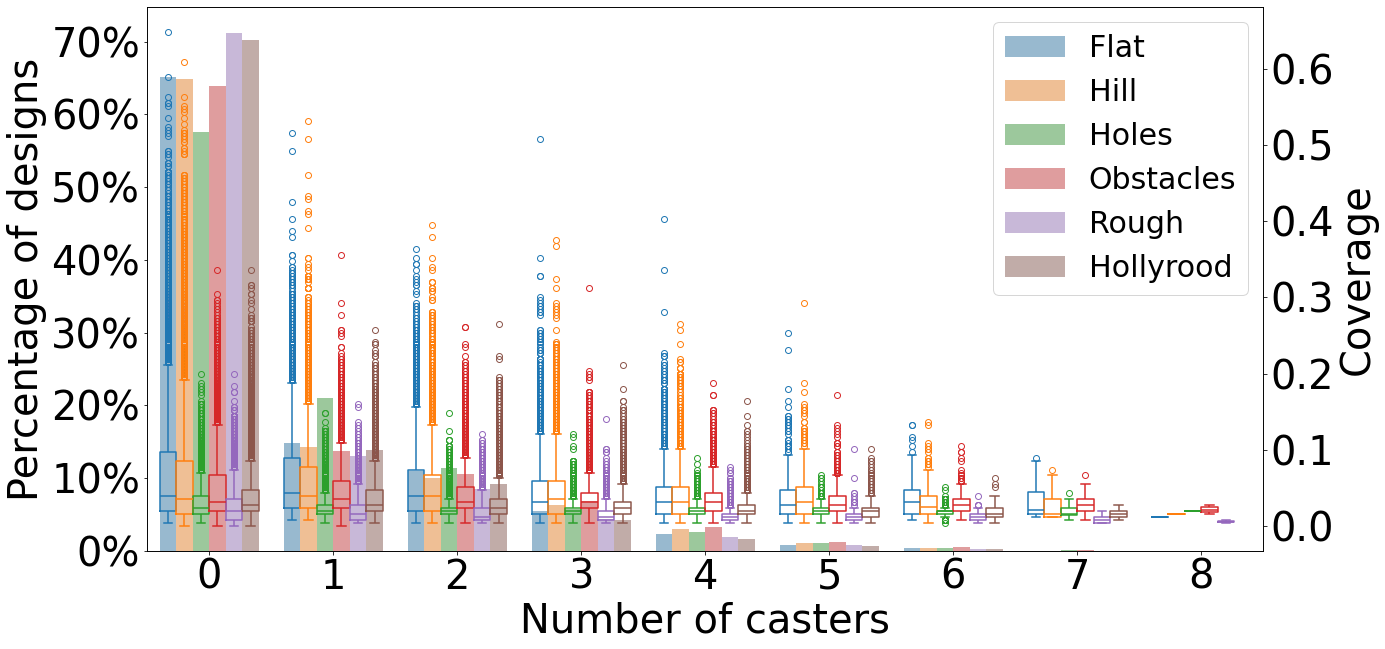

In [24]:
fig = plt.gcf()
fig.set_size_inches(20,10)
df = pd.crosstab(desc_data['environment'], desc_data['casters'], normalize='index')
df1 = df.melt(var_name='casters', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="casters",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(40)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=30)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
ax.xaxis.label.set_size(40)
ax.set_xlabel("Number of casters")
ax.set_ylabel("Percentage of designs")
ax = plt.twinx()
sns.boxplot(data=desc_data,x="casters",y="fitness",hue="environment",ax=ax,fill=False,legend=False)
ax.set_ylabel("Coverage")
ax.yaxis.label.set_size(40)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=40)
plt.savefig("img_alife25/distribution_casters_score.png")

# High coverage diversity

In [29]:
print(desc_data)

         robot index     width     depth    height    voxels  wheels  sensors  \
0                 21  0.909091  0.909091  0.909091  0.458302     0.0      1.0   
1                 45  0.909091  0.909091  0.909091  0.276484     0.0      1.0   
2                 24  0.909091  0.909091  0.909091  0.240421     7.0      0.0   
3                 42  0.909091  0.909091  0.909091  0.252442     0.0      3.0   
4                 60  0.909091  0.727273  0.727273  0.229902     1.0      5.0   
...              ...       ...       ...       ...       ...     ...      ...   
1161915        11514  0.545455  0.727273  0.272727  0.037566     1.0      1.0   
1161916        11496  0.545455  0.909091  0.181818  0.045079     1.0      2.0   
1161917        11516  0.545455  0.909091  0.181818  0.045079     3.0      1.0   
1161918        11502  0.545455  0.909091  0.181818  0.040571     3.0      1.0   
1161919        11517  0.545455  0.545455  0.090909  0.019534     2.0      2.0   

         limbs  casters    

In [55]:
top_percent = 1

df_top = []
for idx, exp in enumerate(experiments["name"]):
     df_tmp = desc_data[desc_data.environment.isin([exp])]
     for rep in df_tmp["replicate"].drop_duplicates():
          df_tmp1 = df_tmp.loc[df_tmp["replicate"] == rep]
          df_top_tmp = df_tmp1.sort_values(by='fitness', ascending=False)
          df_top_tmp = df_top_tmp.head(int(len(df_top_tmp)*(top_percent/100)))
          print(exp,len(df_top_tmp),df_top_tmp.max()["fitness"],df_top_tmp.min()["fitness"])
          df_top.append(df_top_tmp)

df_top = pd.concat(df_top).reset_index(drop=True)
print(len(df_top.index))

flat 100 0.589844 0.308594
flat 100 0.492188 0.253906
flat 100 0.5625 0.300781
flat 100 0.648438 0.273438
flat 100 0.425781 0.246094
flat 100 0.421875 0.253906
flat 100 0.507812 0.273438
flat 100 0.554688 0.304688
flat 100 0.511719 0.304688
flat 100 0.464844 0.25
flat 100 0.46875 0.300781
flat 100 0.570312 0.277344
flat 100 0.453125 0.296875
flat 100 0.378906 0.214844
flat 100 0.4375 0.230469
flat 100 0.667969 0.265625
flat 100 0.457031 0.269531
flat 100 0.433594 0.25
flat 100 0.554688 0.289062
flat 100 0.484375 0.28125


hill 100 0.542969 0.296875
hill 100 0.546875 0.28125
hill 100 0.53125 0.253906
hill 100 0.4375 0.238281
hill 100 0.457031 0.273438
hill 100 0.609375 0.292969
hill 100 0.5625 0.300781
hill 100 0.550781 0.25
hill 100 0.515625 0.265625
hill 100 0.523438 0.292969
hill 100 0.511719 0.304688
hill 100 0.511719 0.226562
hill 100 0.609375 0.328125
hill 100 0.617188 0.300781
hill 100 0.660156 0.3125
hill 100 0.445312 0.246094
hill 100 0.480469 0.25
hill 100 0.410156 0.238281
holes 100 0.152344 0.0898438
holes 100 0.160156 0.0898438
holes 100 0.160156 0.0859375
holes 100 0.179688 0.101562
holes 100 0.199219 0.101562
holes 100 0.148438 0.09375
holes 100 0.183594 0.109375
holes 100 0.160156 0.09375
holes 100 0.171875 0.0898438
holes 100 0.1875 0.0859375
holes 100 0.171875 0.105469
holes 100 0.15625 0.0898438
holes 100 0.164062 0.0898438
holes 100 0.160156 0.09375
holes 100 0.160156 0.0898438
holes 100 0.175781 0.0859375
holes 100 0.160156 0.0859375
holes 100 0.132812 0.0898438
holes 100 0.136719 0.

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.7000000000000001, '70%'),
  Text(0, 0.8, '80%'),
  Text(0, 0.9, '90%')])

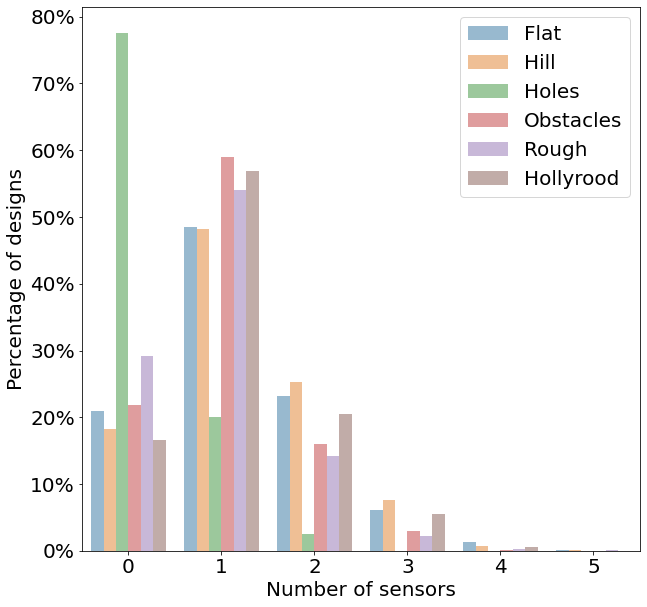

In [59]:
fig = plt.gcf()
fig.set_size_inches(10,10)
df = pd.crosstab(df_top['environment'], df_top['sensors'], normalize='index')
df1 = df.melt(var_name='sensors', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="sensors",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of sensors")
ax.set_ylabel("Percentage of designs")
# ax.set_xlim([-0.5,4.5])
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

/tmp/ipykernel_3806282/3789371533.py:9: UserWarning: Mismatched number of handles and labels: len(handles) = 0 len(labels) = 6
  ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
/tmp/ipykernel_3806282/3789371533.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)


(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.05, '5%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.15000000000000002, '15%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.25, '25%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.35000000000000003, '35%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.45, '45%')])

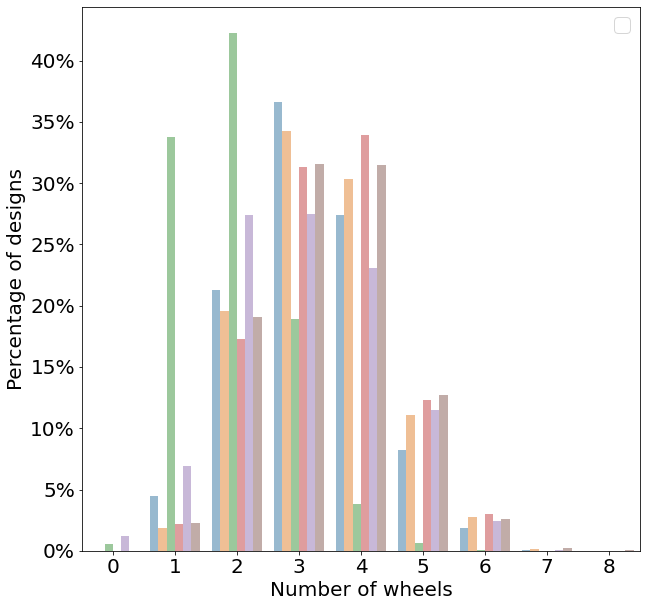

In [58]:
fig = plt.gcf()
fig.set_size_inches(10,10)
df = pd.crosstab(df_top['environment'], df_top['wheels'], normalize='index')
df1 = df.melt(var_name='wheels', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="wheels",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5,legend=False)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of wheels")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.1, '10%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.30000000000000004, '30%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.5, '50%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.7000000000000001, '70%'),
  Text(0, 0.8, '80%'),
  Text(0, 0.9, '90%')])

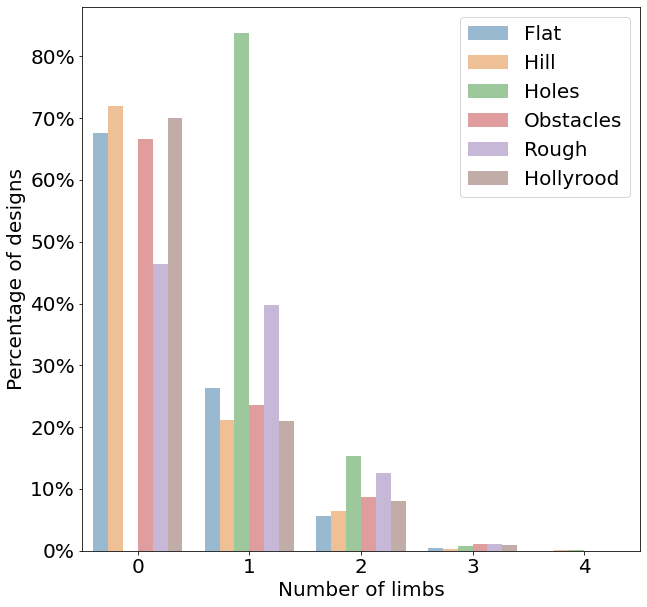

In [60]:
fig = plt.gcf()
fig.set_size_inches(10,10)
df = pd.crosstab(df_top['environment'], df_top['limbs'], normalize='index')
df1 = df.melt(var_name='limbs', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="limbs",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of limbs")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(0, 0.0, '0%'),
  Text(0, 0.2, '20%'),
  Text(0, 0.4, '40%'),
  Text(0, 0.6000000000000001, '60%'),
  Text(0, 0.8, '80%'),
  Text(0, 1.0, '100%')])

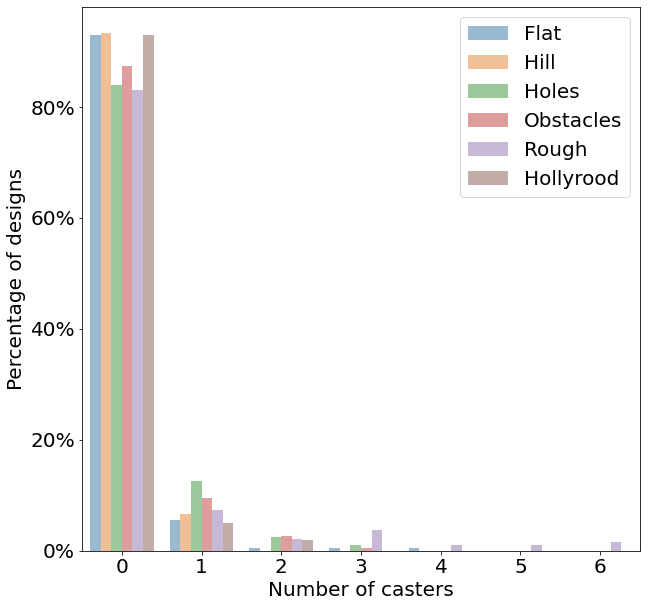

In [46]:
fig = plt.gcf()
fig.set_size_inches(10,10)
df = pd.crosstab(df_top_desc_data['environment'], df_top_desc_data['casters'], normalize='index')
df1 = df.melt(var_name='limbs', value_name='percentage', ignore_index=False).reset_index()
ax = sns.barplot(data=df1,x="limbs",y="percentage",hue="environment",hue_order=experiments["name"],alpha=0.5)
ax.yaxis.label.set_size(20)
ax.yaxis.set_major_formatter('{x:.0%}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles,labels=experiments["print_name"],fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Number of casters")
ax.set_ylabel("Percentage of designs")
ax.yaxis.label.set_size(20)
ax.xaxis.set_major_formatter('{x:}')
plt.yticks(fontsize=20)

<Figure size 1440x360 with 0 Axes>

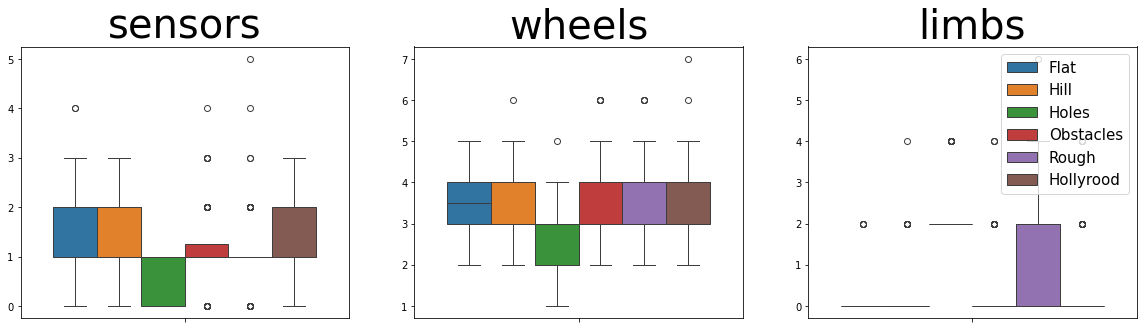

In [14]:
fig = plt.gcf()
fig.set_size_inches(20,5)
plt.figure(figsize=(20,5))
variables = ["sensors", "wheels", "limbs"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(1,3,i)
    is_legend = False
    if i == 3:
        is_legend = True
    sns.boxplot(y=c, hue="environment", data=df_top_desc_data, legend=is_legend)
    if i == 3:
      plt.legend(loc='upper right', fontsize=15, labels=experiments["print_name"])
    plt.title(c, fontsize=40)
    plt.ylabel("")
    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
#plt.savefig("img_alife25/high_coverage_diversity_" + str(top_percent) + ".png", bbox_inches='tight')

In [68]:
# Window of 10% ordered by fitness
windows = 10
window_size = []
for idx, exp in enumerate(experiments["name"]):
    window_size.append(int(desc_data[desc_data.environment.isin([exp])].shape[0] / windows))
feats = ["wheels", "sensors", "limbs"]
wheels = []
sensors = []
limbs = []
for window in range(windows):
    temp = []
    for idx, exp in enumerate(experiments["name"]):
        temp = desc_data[desc_data.environment.isin([exp])].sort_values(by=['replicate_index'], ascending=True)[window_size[idx] * window : window_size[idx] * (window + 1)]
        wheels.append([temp.wheels.mean(), temp.wheels.std(), temp.wheels.median(), temp.wheels.mode()[0], temp.wheels.quantile(0.75) - temp.wheels.quantile(0.25), temp.wheels.var(), window, exp, "wheels"])
        sensors.append([temp.sensors.mean(), temp.sensors.std(), temp.sensors.median(), temp.sensors.mode()[0], temp.sensors.quantile(0.75) - temp.sensors.quantile(0.25), temp.sensors.var(), window, exp, "sensors"])
        limbs.append([temp.limbs.mean(), temp.limbs.std(), temp.limbs.median(), temp.limbs.mode()[0], temp.limbs.quantile(0.75) - temp.limbs.quantile(0.25), temp.limbs.var(), window, exp, "limbs"])

wheels = pd.DataFrame(data=wheels, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
sensors = pd.DataFrame(data=sensors, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
limbs = pd.DataFrame(data=limbs, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
windowed_data = pd.concat([wheels, sensors, limbs]).reset_index(drop=True)
#windowed_data = pd.DataFrame(data=windowed_data, columns=["mean", "window", "environment", "feature"])
#print(windowed_data)

<Figure size 1440x360 with 0 Axes>

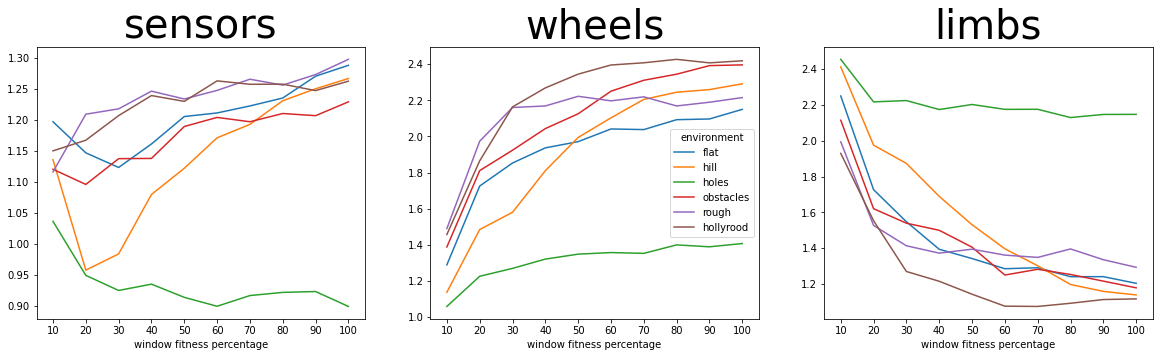

In [69]:
fig = plt.gcf()
fig.set_size_inches(20,5)
plt.figure(figsize=(20,5))
variables = [ "sensors", "wheels", "limbs"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(1,3,i)
    is_legend = False
    if i == 2:
        is_legend = True
        plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    ax = sns.lineplot(data=windowed_data[windowed_data["feature"] == c], x="window", y="mean", hue="environment", legend=is_legend)
    
    #plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax.errorbar(windowed_data[windowed_data["feature"] == c]["window"], windowed_data[windowed_data["feature"] == c]["mean"], yerr= windowed_data[windowed_data["feature"] == c]["std"],fmt='o')
    
    plt.title(c, fontsize=40)
    plt.ylabel("")
    plt.xlabel("window fitness percentage")
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['10','20', '30', '40', '50', '60', '70', '80', '90', '100'])

    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
plt.savefig("img_alife25/features_trend_percentage_window.png", bbox_inches='tight')

In [65]:
# Window of 10% ordered by fitness
windows = 10
window_size = []
for idx, exp in enumerate(experiments["name"]):
    window_size.append(int(desc_data[desc_data.environment.isin([exp])].shape[0] / windows))
feats = ["wheels", "sensors", "limbs"]
wheels = []
sensors = []
limbs = []
for window in range(windows):
    temp = []
    for idx, exp in enumerate(experiments["name"]):
        temp = desc_data[desc_data.environment.isin([exp])].sort_values(by=['fitness'], ascending=True)[window_size[idx] * window : window_size[idx] * (window + 1)]
        wheels.append([temp.wheels.mean(), temp.wheels.std(), temp.wheels.median(), temp.wheels.mode()[0], temp.wheels.quantile(0.75) - temp.wheels.quantile(0.25), temp.wheels.var(), window, exp, "wheels"])
        sensors.append([temp.sensors.mean(), temp.sensors.std(), temp.sensors.median(), temp.sensors.mode()[0], temp.sensors.quantile(0.75) - temp.sensors.quantile(0.25), temp.sensors.var(), window, exp, "sensors"])
        limbs.append([temp.limbs.mean(), temp.limbs.std(), temp.limbs.median(), temp.limbs.mode()[0], temp.limbs.quantile(0.75) - temp.limbs.quantile(0.25), temp.limbs.var(), window, exp, "limbs"])

wheels = pd.DataFrame(data=wheels, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
sensors = pd.DataFrame(data=sensors, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
limbs = pd.DataFrame(data=limbs, columns=["mean", "std", "median", "mode", "IQR", "var",  "window", "environment", "feature"])
windowed_data = pd.concat([wheels, sensors, limbs]).reset_index(drop=True)
#windowed_data = pd.DataFrame(data=windowed_data, columns=["mean", "window", "environment", "feature"])
#print(windowed_data)

<Figure size 1440x360 with 0 Axes>

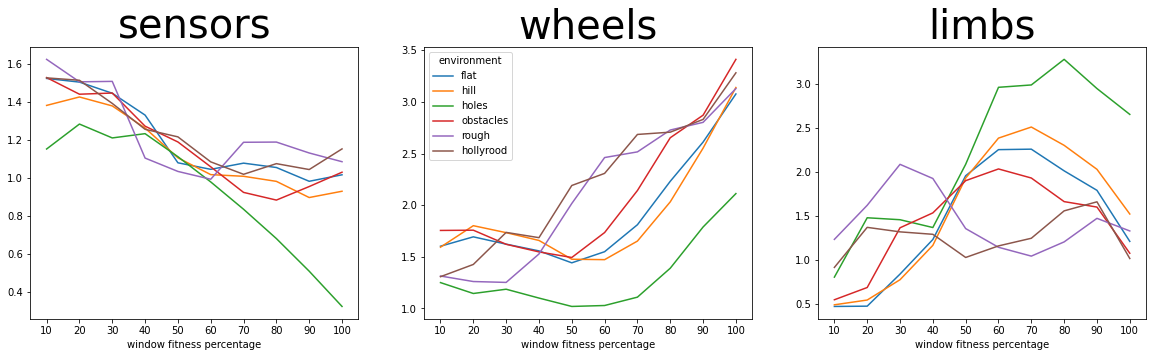

In [96]:
fig = plt.gcf()
fig.set_size_inches(20,5)
plt.figure(figsize=(20,5))
variables = [ "sensors", "wheels", "limbs"]#,"casters"]
for i, c in enumerate(variables, 1):
    plt.subplot(1,3,i)
    is_legend = False
    if i == 2:
        is_legend = True
        plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    ax = sns.lineplot(data=windowed_data[windowed_data["feature"] == c], x="window", y="mean", hue="environment", legend=is_legend)
    
    #plt.legend(loc='upper left', fontsize=15, labels=experiments["print_name"])
    #ax.errorbar(windowed_data[windowed_data["feature"] == c]["window"], windowed_data[windowed_data["feature"] == c]["mean"], yerr= windowed_data[windowed_data["feature"] == c]["std"],fmt='o')
    
    plt.title(c, fontsize=40)
    plt.ylabel("")
    plt.xlabel("window fitness percentage")
    plt.xlim(-0.5, 9.5)
    plt.xticks([0,1,2,3,4,5,6,7,8,9], ['10','20', '30', '40', '50', '60', '70', '80', '90', '100'])

    #plt.suptitle("Top " + str(top_percent) + "%", fontsize=32)
plt.savefig("img_alife25/features_trend_percentage_window.png", bbox_inches='tight')

In [63]:
windowed_data

,mean,std,median,mode,IQR,var,window,environment,feature
0,1.601938,1.111142,1.0,1.0,1.0,1.234638,0,flat,wheels
1,1.592848,1.149166,1.0,1.0,1.0,1.320582,0,hill,wheels
2,1.249551,0.975039,1.0,1.0,1.0,0.950701,0,holes,wheels
3,1.754870,1.282030,2.0,1.0,2.0,1.643601,0,obstacles,wheels
4,1.313367,1.047131,1.0,1.0,1.0,1.096484,0,rough,wheels
...,...,...,...,...,...,...,...,...,...
175,1.524558,1.711290,2.0,0.0,2.0,2.928515,9,hill,limbs
176,2.656281,1.113140,2.0,2.0,2.0,1.239081,9,holes,limbs
177,1.078614,1.521249,0.0,0.0,2.0,2.314199,9,obstacles,limbs
178,1.332060,1.530107,2.0,0.0,2.0,2.341228,9,rough,limbs


(array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.2000000000000002, '1.2'),
  Text(0, 1.4000000000000001, '1.4'),
  Text(0, 1.6, '1.6'),
  Text(0, 1.8, '1.8')])

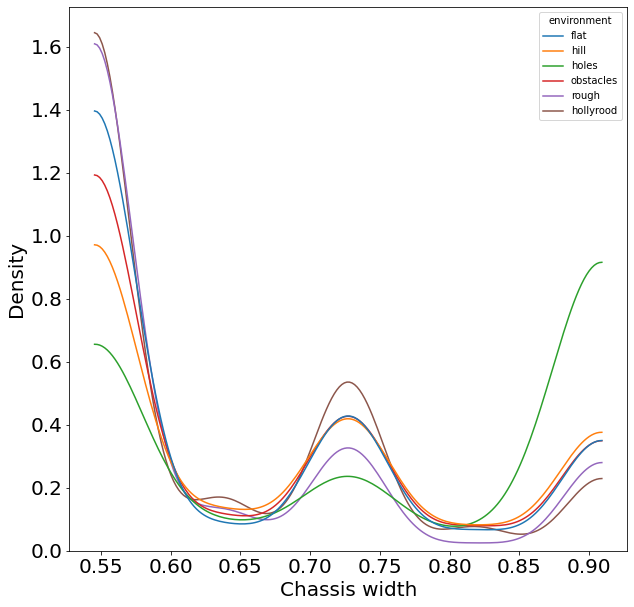

In [ ]:
fig = plt.gcf()
fig.set_size_inches(10,10)
ax = sns.kdeplot(data=df_top,x="width",hue="environment",cut=0,hue_order=experiments["name"])
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis width")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.2000000000000002, '1.2'),
  Text(0, 1.4000000000000001, '1.4')])

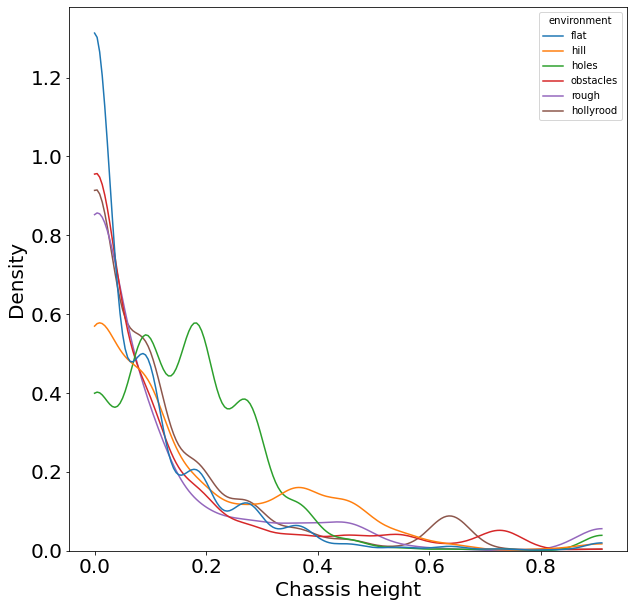

In [62]:
fig = plt.gcf()
fig.set_size_inches(10,10)
ax = sns.kdeplot(data=df_top,x="height",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis height")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6]),
 [Text(0, 0.0, '0.0'),
  Text(0, 0.2, '0.2'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.8, '0.8'),
  Text(0, 1.0, '1.0'),
  Text(0, 1.2000000000000002, '1.2'),
  Text(0, 1.4000000000000001, '1.4'),
  Text(0, 1.6, '1.6')])

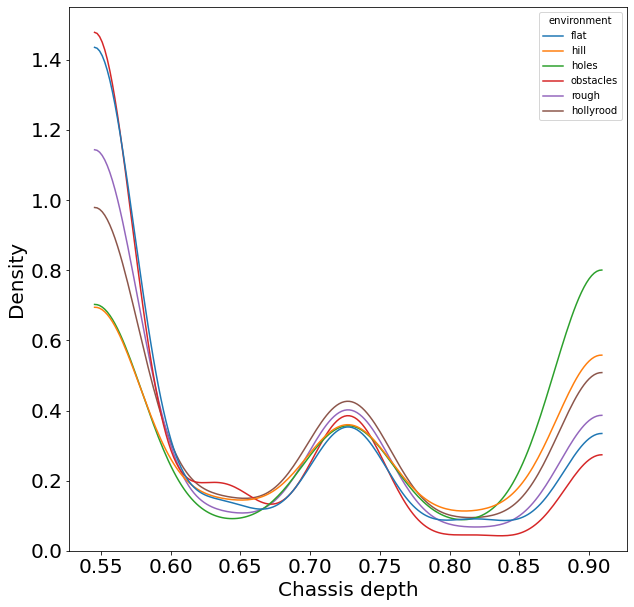

In [63]:
fig = plt.gcf()
fig.set_size_inches(10,10)
ax = sns.kdeplot(data=df_top,x="depth",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis depth")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

(array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14.]),
 [Text(0, 0.0, '0'),
  Text(0, 2.0, '2'),
  Text(0, 4.0, '4'),
  Text(0, 6.0, '6'),
  Text(0, 8.0, '8'),
  Text(0, 10.0, '10'),
  Text(0, 12.0, '12'),
  Text(0, 14.0, '14')])

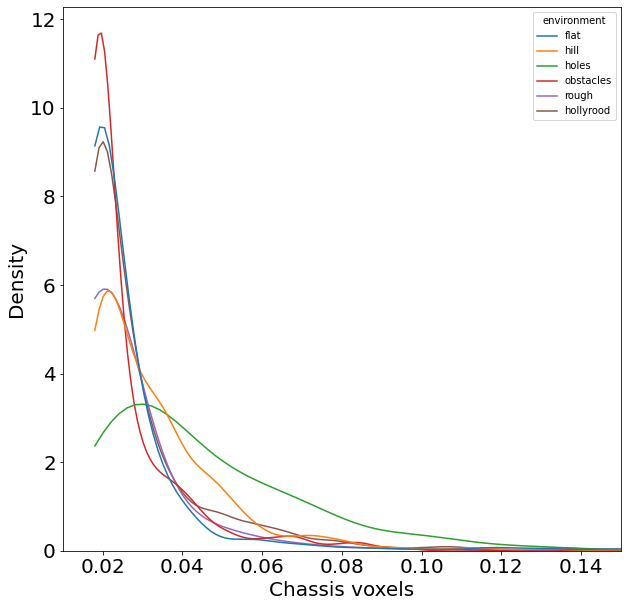

In [64]:
fig = plt.gcf()
fig.set_size_inches(10,10)
ax = sns.kdeplot(data=df_top,x="voxels",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.set_xlim(0.01,0.15)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis voxels")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

# Chassis diversity

KeyboardInterrupt: 

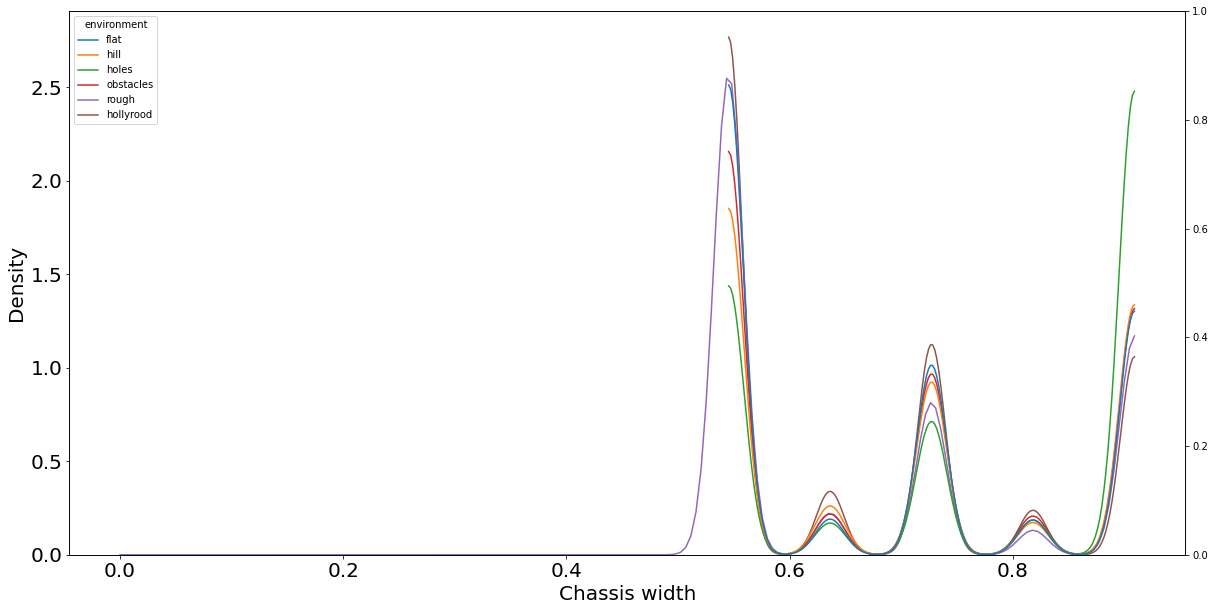

In [25]:
fig = plt.gcf()
fig.set_size_inches(20,10)
ax = sns.kdeplot(data=desc_data,x="width",hue="environment",cut=0,hue_order=experiments["name"])
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis width")
ax = plt.twinx()
sns.df_top_desc_data(data=desc_data,x="width",y="fitness",hue="environment",ax=ax,s=10,legend=False,cut=0,alpha=0.4,fill=True,linewidth=0,hue_order=experiments["name"])
ax.set_ylabel("Coverage")
ax.set_ylabel("Exploration score")
ax.set_xlim([0.4,1])
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

(array([-0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7]),
 [Text(1, -0.1, '−0.1'),
  Text(1, 0.0, '0.0'),
  Text(1, 0.1, '0.1'),
  Text(1, 0.20000000000000004, '0.2'),
  Text(1, 0.30000000000000004, '0.3'),
  Text(1, 0.4, '0.4'),
  Text(1, 0.5000000000000001, '0.5'),
  Text(1, 0.6000000000000001, '0.6'),
  Text(1, 0.7000000000000001, '0.7')])

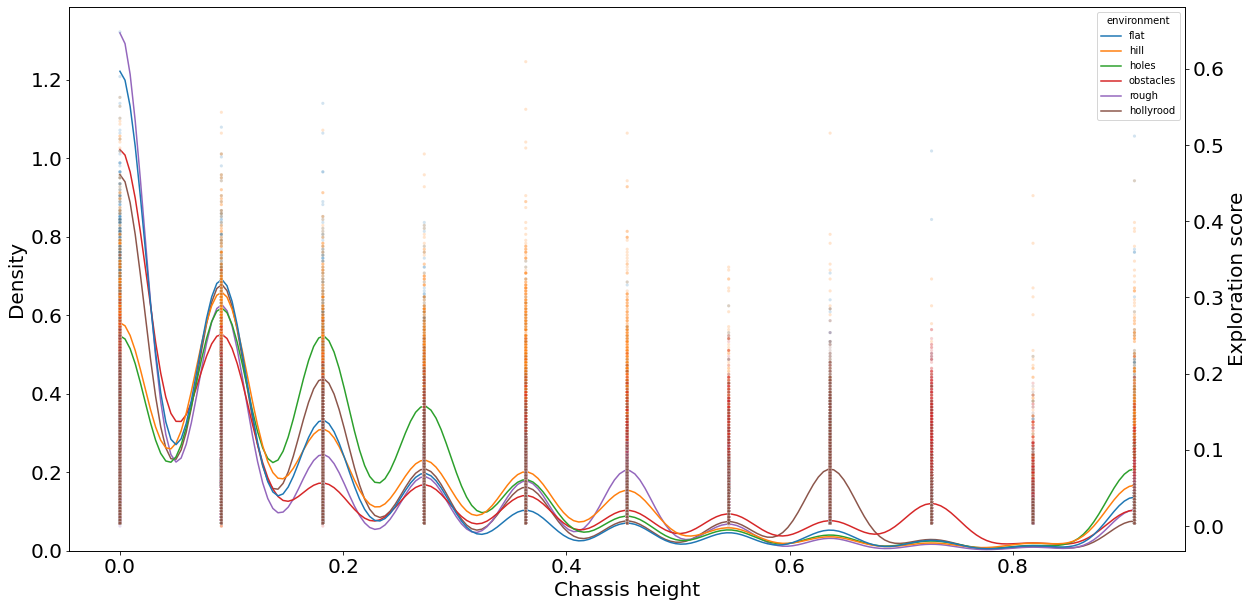

In [ ]:
fig = plt.gcf()
fig.set_size_inches(20,10)
ax = sns.kdeplot(data=desc_data,x="height",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis height")
ax = plt.twinx()
sns.kdeplot(data=desc_data,x="height",y="fitness",hue="environment",ax=ax,s=10,legend=False,legend=False,cut=0,alpha=0.4,fill=True,linewidth=0)
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

(array([-0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7]),
 [Text(1, -0.1, '−0.1'),
  Text(1, 0.0, '0.0'),
  Text(1, 0.1, '0.1'),
  Text(1, 0.20000000000000004, '0.2'),
  Text(1, 0.30000000000000004, '0.3'),
  Text(1, 0.4, '0.4'),
  Text(1, 0.5000000000000001, '0.5'),
  Text(1, 0.6000000000000001, '0.6'),
  Text(1, 0.7000000000000001, '0.7')])

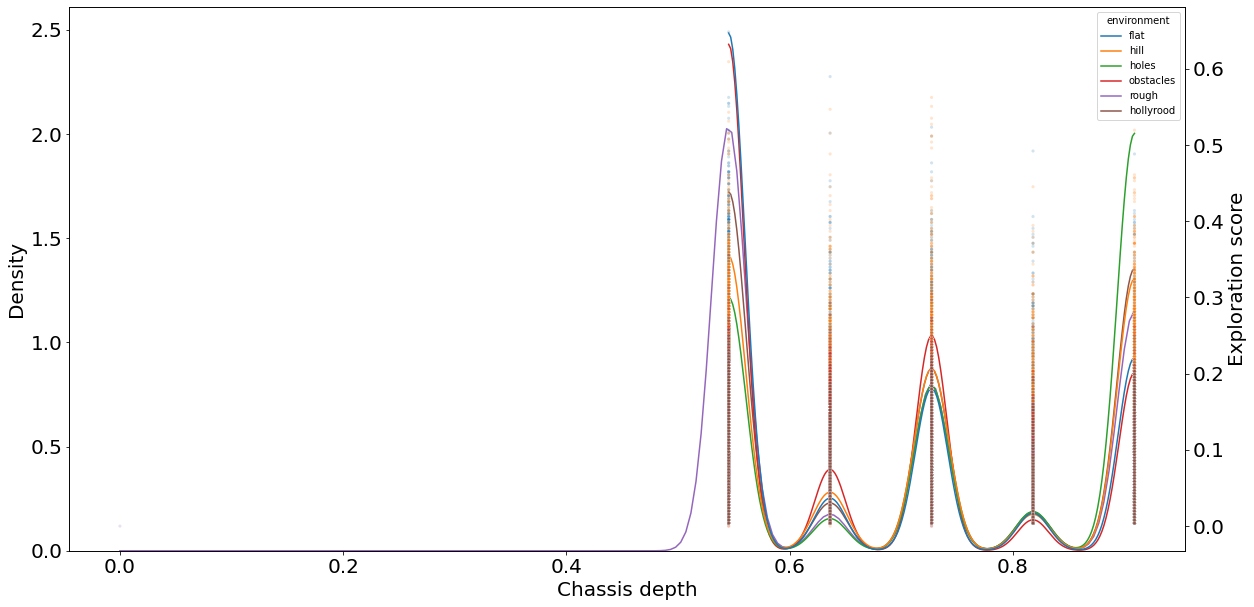

In [ ]:
fig = plt.gcf()
fig.set_size_inches(20,10)
ax = sns.kdeplot(data=desc_data,x="depth",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlim([0.4,1])
ax.set_xlabel("Chassis depth")
ax = plt.twinx()
sns.kdeplot(data=desc_data,x="depth",y="fitness",hue="environment",ax=ax,s=10,legend=False,legend=False,legend=False,cut=0,alpha=0.4,fill=True,linewidth=0)
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

(array([0. , 0.2, 0.4, 0.6, 0.8, 1. ]),
 [Text(1, 0.0, '0.0'),
  Text(1, 0.2, '0.2'),
  Text(1, 0.4, '0.4'),
  Text(1, 0.6000000000000001, '0.6'),
  Text(1, 0.8, '0.8'),
  Text(1, 1.0, '1.0')])

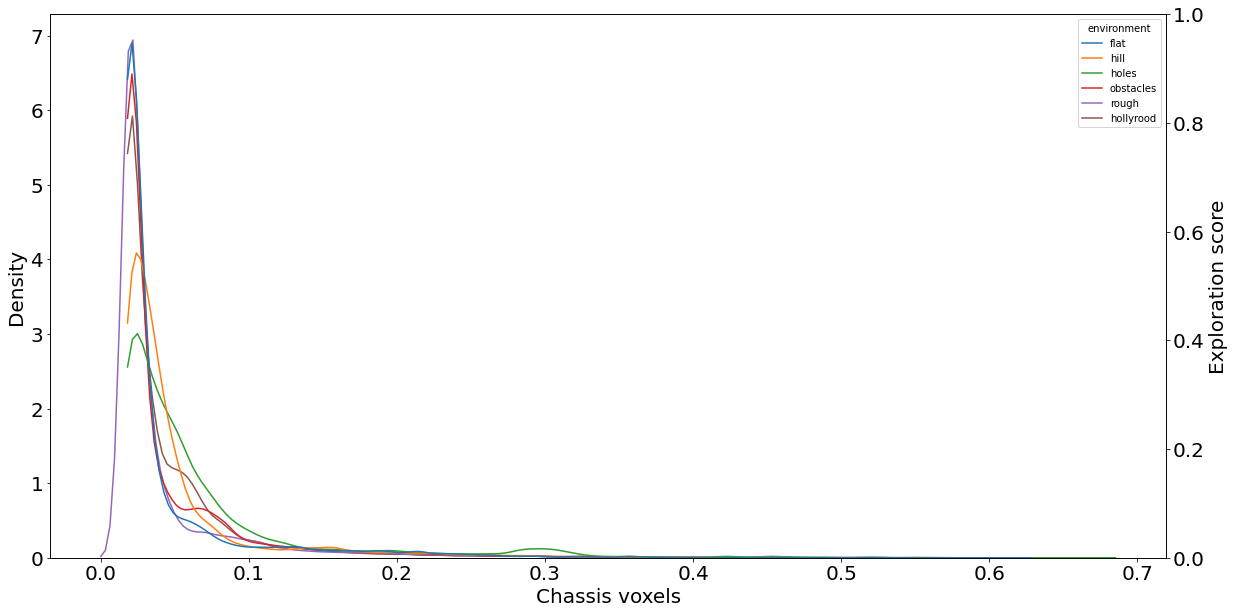

In [18]:
fig = plt.gcf()
fig.set_size_inches(20,10)
sns.scatterplot(data=desc_data,x="voxels",y="fitness",hue="environment",ax=ax,s=10,legend=False,alpha=0.2)
ax = sns.kdeplot(data=desc_data,x="voxels",hue="environment",cut=0)
ax.yaxis.label.set_size(20)
#plt.legend(["flat","terrain 1","terrain 2","terrain 3"],fontsize=20,loc=2)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
ax.xaxis.label.set_size(20)
ax.set_xlabel("Chassis voxels")
ax = plt.twinx()
ax.set_ylabel("Exploration score")
ax.yaxis.label.set_size(20)
plt.yticks(fontsize=20)

# Trajectories

In [ ]:
import importlib
importlib.reload(medf)  

<module 'me_data_fcts' from '/are/AREFramework/experiments/scripts/me_data_fcts.py'>

: 

: 

In [ ]:
#%%px --targets 0 --noblock
# repo_folder = "/home/leni/remote-logs/"
# mehk_t1_folder = repo_folder + "mehk_terrains/terrain_1"
parent_fits = []
trajectories = []
for folder in os.listdir(mehk_t1_folder):
    print(folder)
    for file in os.listdir(mehk_t1_folder + "/" + folder):
        if file.split("_")[0] == "traj":
            print(file)
            trajectories +=  [[int(file.split("_")[1])] + t for t in medf.load_trajectory(mehk_t1_folder + "/" + folder + "/" + file,10)]
    
traj_data1 = pd.DataFrame(data=trajectories,columns=["robot index","iteration","x","y","z"])


NameError: name 'mehk_t1_folder' is not defined

: 

: 

In [ ]:
%%px --targets 1 --noblock
repo_folder = "/home/leni/remote-logs/"
mehk_t2_folder = repo_folder + "mehk_terrains/terrain_2"
parent_fits = []
trajectories = []
for folder in os.listdir(mehk_t2_folder):
    print(folder)
    for file in os.listdir(mehk_t2_folder + "/" + folder):
        if file.split("_")[0] == "traj":
            print(file)
            trajectories +=  [[int(file.split("_")[1])] + t for t in me_data_fcts.load_trajectory(mehk_t2_folder + "/" + folder + "/" + file,100)]
    
traj_data2 = pd.DataFrame(data=trajectories,columns=["robot index","iteration","x","y","z"])

<AsyncResult(%px): pending>

: 

: 

In [ ]:
%%px --targets 2 --noblock
repo_folder = "/home/leni/remote-logs/"
mehk_t3_folder = repo_folder + "mehk_terrains/terrain_3"
parent_fits = []
trajectories = []
for folder in os.listdir(mehk_t3_folder):
    print(folder)
    for file in os.listdir(mehk_t3_folder + "/" + folder):
        if file.split("_")[0] == "traj":
            print(file)
            trajectories +=  [[int(file.split("_")[1])] + t for t in me_data_fcts.load_trajectory(mehk_t2_folder + "/" + folder + "/" + file,100)]
    
traj_data3 = pd.DataFrame(data=trajectories,columns=["robot index","iteration","x","y","z"])

<AsyncResult(%px): pending>

: 

: 

In [ ]:
fig = plt.gcf()
fig.set_size_inches(20,10)
fg = sns.displot(data=traj_data,x="x",y="y",col="environment",kind="hist",binwidth=0.25,aspect=1)
fg.set(xlim=[-2,2],ylim=[-2,2])

: 

: 

: 

: 